# Airline Delay & Operations Analysis

Rishabh Pandey — Data Analyst Project

Dataset: [Flight Delay and Cancellation Dataset (2019-2023)](https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023) via `kagglehub`.

## Step 1: Setup & Data Loading

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("patrickzel/flight-delay-and-cancellation-dataset-2019-2023")
print("Path to dataset files:", path)

100%|██████████| 140M/140M [00:49<00:00, 2.93MB/s] 

Extracting files...


Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\patrickzel\flight-delay-and-cancellation-dataset-2019-2023\versions\7


In [2]:
import os
print(os.listdir(path))

['dictionary.html', 'flights_sample_3m.csv']


In [3]:
import pandas as pd
import numpy as np

# This dataset ships as a single CSV (flights_sample_3m.csv)
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
flights = pd.read_csv(os.path.join(path, csv_file), low_memory=False)

print("Shape:", flights.shape)
flights.info()

Shape: (3000000, 32)
<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  str    
 1   AIRLINE                  str    
 2   AIRLINE_DOT              str    
 3   AIRLINE_CODE             str    
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   str    
 7   ORIGIN_CITY              str    
 8   DEST                     str    
 9   DEST_CITY                str    
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21

In [ ]:
# IMPORTANT: verify actual column names before proceeding —
# BTS-derived datasets sometimes vary slightly between uploads/versions
print(list(flights.columns))

In [ ]:
flights.head()

## Step 2: Data Cleaning

Expected columns for this dataset: `FL_DATE`, `AIRLINE`, `AIRLINE_CODE`, `ORIGIN`, `ORIGIN_CITY`, `DEST`, `DEST_CITY`, `CRS_DEP_TIME`, `DEP_TIME`, `DEP_DELAY`, `ARR_TIME`, `ARR_DELAY`, `CANCELLED`, `CANCELLATION_CODE`, `DIVERTED`, `AIR_TIME`, `DISTANCE`, `DELAY_DUE_CARRIER`, `DELAY_DUE_WEATHER`, `DELAY_DUE_NAS`, `DELAY_DUE_SECURITY`, `DELAY_DUE_LATE_AIRCRAFT`.

**If the printed column list above differs, rename here before continuing.**

In [7]:
print(flights.isnull().sum().sort_values(ascending=False).head(15))

CANCELLATION_CODE          2920860
DELAY_DUE_LATE_AIRCRAFT    2466137
DELAY_DUE_CARRIER          2466137
DELAY_DUE_SECURITY         2466137
DELAY_DUE_NAS              2466137
DELAY_DUE_WEATHER          2466137
ARR_DELAY                    86198
ELAPSED_TIME                 86198
AIR_TIME                     86198
WHEELS_ON                    79944
TAXI_IN                      79944
ARR_TIME                     79942
WHEELS_OFF                   78806
TAXI_OUT                     78806
DEP_DELAY                    77644
dtype: int64


In [8]:
flights_clean = flights[(flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)].copy()

flights_clean['FL_DATE'] = pd.to_datetime(flights_clean['FL_DATE'])
flights_clean['MONTH'] = flights_clean['FL_DATE'].dt.month
flights_clean['YEAR'] = flights_clean['FL_DATE'].dt.year
flights_clean['DAY_OF_WEEK_NAME'] = flights_clean['FL_DATE'].dt.day_name()

delay_cols = ['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
              'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']
flights_clean[delay_cols] = flights_clean[delay_cols].fillna(0)

flights_clean = flights_clean.dropna(subset=['ARR_DELAY'])

print("Cleaned shape:", flights_clean.shape)
flights_clean.head()

Cleaned shape: (2913802, 35)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,MONTH,YEAR,DAY_OF_WEEK_NAME
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,153.0,1065.0,0.0,0.0,0.0,0.0,0.0,1,2019,Wednesday
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,189.0,1399.0,0.0,0.0,0.0,0.0,0.0,11,2022,Saturday
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,87.0,680.0,0.0,0.0,0.0,0.0,0.0,7,2022,Friday
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,249.0,1589.0,0.0,0.0,24.0,0.0,0.0,3,2023,Monday
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,153.0,985.0,0.0,0.0,0.0,0.0,0.0,2,2020,Sunday


In [18]:
import os
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
flights_clean.to_csv('outputs/cleaned_flights.csv', index=False)

## Step 3: Delay-Cause Breakdown

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20104\958644051.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_totals.values, y=delay_totals.index, palette='viridis')


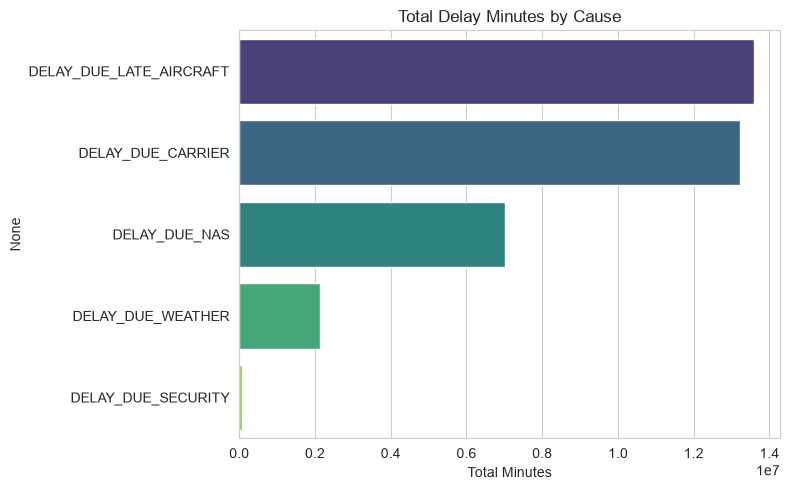

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

delay_totals = flights_clean[delay_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=delay_totals.values, y=delay_totals.index, palette='viridis')
plt.title('Total Delay Minutes by Cause')
plt.xlabel('Total Minutes')
plt.tight_layout()
plt.savefig('outputs/figures/delay_cause_breakdown.png', dpi=150)
plt.show()

## Step 4: Seasonal Trends

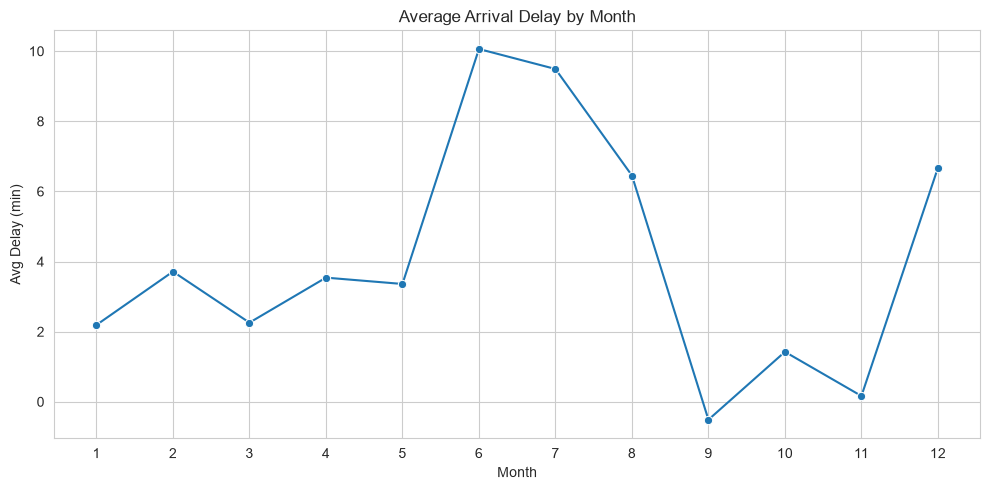

In [10]:
monthly_delay = flights_clean.groupby('MONTH')['ARR_DELAY'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_delay.index, y=monthly_delay.values, marker='o')
plt.title('Average Arrival Delay by Month')
plt.xlabel('Month')
plt.ylabel('Avg Delay (min)')
plt.xticks(range(1,13))
plt.tight_layout()
plt.savefig('outputs/figures/seasonal_trend.png', dpi=150)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20104\2607254876.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_delay.index, y=dow_delay.values, palette='mako')


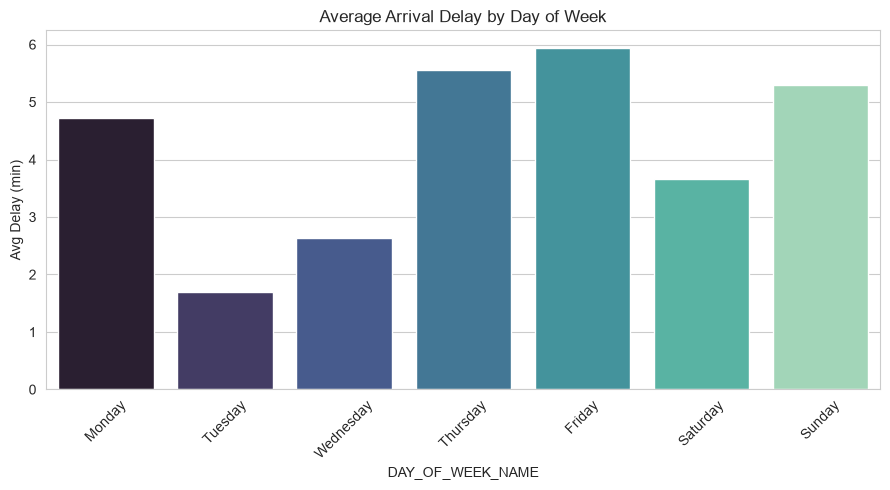

In [11]:
dow_delay = flights_clean.groupby('DAY_OF_WEEK_NAME')['ARR_DELAY'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(9,5))
sns.barplot(x=dow_delay.index, y=dow_delay.values, palette='mako')
plt.title('Average Arrival Delay by Day of Week')
plt.ylabel('Avg Delay (min)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/figures/dow_trend.png', dpi=150)
plt.show()

## Step 5: Route-Level Trends

In [12]:
flights_clean['ROUTE'] = flights_clean['ORIGIN'] + ' → ' + flights_clean['DEST']

route_delay = flights_clean.groupby('ROUTE').agg(
    avg_delay=('ARR_DELAY', 'mean'),
    flight_count=('ARR_DELAY', 'count')
).query('flight_count >= 100').sort_values('avg_delay', ascending=False)

print("Top 10 worst routes:")
print(route_delay.head(10))

print("\nTop 10 best routes:")
print(route_delay.tail(10))

Top 10 worst routes:
           avg_delay  flight_count
ROUTE                             
ABQ → JFK  40.100917           109
ACK → LGA  38.880597           134
ASE → ORD  38.536111           360
BDL → SJU  37.036667           300
ONT → JFK  36.376068           117
IAD → SHD  34.970588           136
SJU → DCA  33.238411           151
ASE → DFW  33.197297           370
CHO → ORD  33.000000           135
ASE → SFO  31.689394           132

Top 10 best routes:
           avg_delay  flight_count
ROUTE                             
HNL → SLC -11.474026           154
KOA → PHX -11.586207           174
MSP → MQT -11.636364           110
IMT → DTW -11.682432           148
VCT → IAH -12.147239           163
MSP → DAY -12.566176           136
SBN → MSP -12.884211           190
FNT → ATL -13.455782           147
LIH → DEN -14.189394           132
ABE → CLT -14.505330           469


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20104\2400655603.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=route_delay.head(10)['avg_delay'], y=route_delay.head(10).index, palette='rocket')


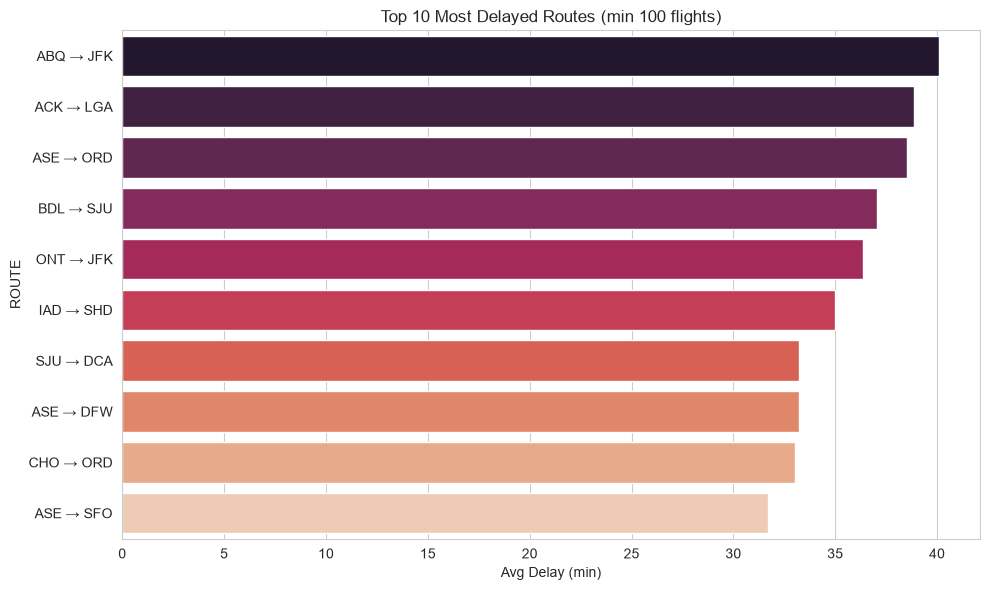

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(x=route_delay.head(10)['avg_delay'], y=route_delay.head(10).index, palette='rocket')
plt.title('Top 10 Most Delayed Routes (min 100 flights)')
plt.xlabel('Avg Delay (min)')
plt.tight_layout()
plt.savefig('outputs/figures/worst_routes.png', dpi=150)
plt.show()

## Step 6: Carrier On-Time Performance

In [14]:
flights_clean['ON_TIME'] = flights_clean['ARR_DELAY'] <= 15

carrier_perf = flights_clean.groupby('AIRLINE').agg(
    avg_delay=('ARR_DELAY', 'mean'),
    on_time_pct=('ON_TIME', 'mean'),
    total_flights=('ARR_DELAY', 'count')
).sort_values('on_time_pct', ascending=False)

carrier_perf['on_time_pct'] = (carrier_perf['on_time_pct'] * 100).round(2)
print(carrier_perf)

                                    avg_delay  on_time_pct  total_flights
AIRLINE                                                                  
Endeavor Air Inc.                   -1.258539        87.38         109848
Horizon Air                          2.376242        86.21          20237
Delta Air Lines Inc.                 1.085079        86.15         388475
Republic Airline                     0.590176        84.71         138147
SkyWest Airlines Inc.                4.023311        84.65         334986
Hawaiian Airlines Inc.               3.894757        84.52          31698
Envoy Air                            3.278914        83.26         117312
PSA Airlines Inc.                    3.928655        83.25         103483
Alaska Airlines Inc.                 1.097900        82.62          98294
Mesa Airlines Inc.                   7.309810        81.94          62477
United Air Lines Inc.                5.035985        81.46         248270
Southwest Airlines Co.               3

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20104\4208000883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=carrier_perf['on_time_pct'], y=carrier_perf.index, palette='crest')


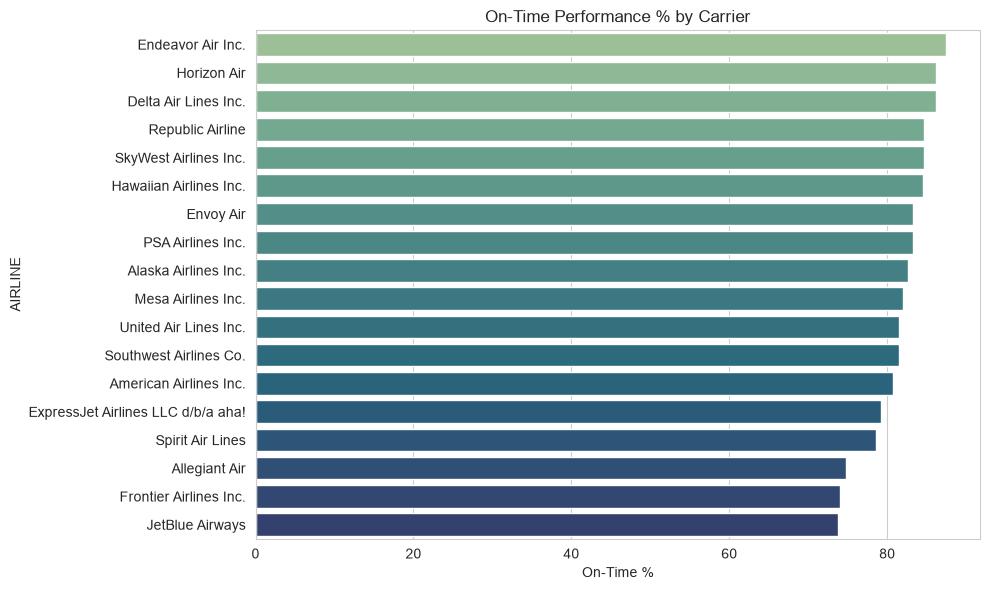

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(x=carrier_perf['on_time_pct'], y=carrier_perf.index, palette='crest')
plt.title('On-Time Performance % by Carrier')
plt.xlabel('On-Time %')
plt.tight_layout()
plt.savefig('outputs/figures/carrier_ontime.png', dpi=150)
plt.show()

In [16]:
cancel_rate = flights.groupby('AIRLINE')['CANCELLED'].mean().sort_values(ascending=False)
cancel_rate = (cancel_rate * 100).round(2)
print(cancel_rate)

AIRLINE
ExpressJet Airlines LLC d/b/a aha!    5.57
Allegiant Air                         4.52
Mesa Airlines Inc.                    3.65
Southwest Airlines Co.                3.38
Republic Airline                      3.25
PSA Airlines Inc.                     3.08
Envoy Air                             3.00
American Airlines Inc.                2.85
JetBlue Airways                       2.69
Frontier Airlines Inc.                2.58
Spirit Air Lines                      2.42
SkyWest Airlines Inc.                 2.25
United Air Lines Inc.                 2.18
Endeavor Air Inc.                     2.13
Alaska Airlines Inc.                  1.93
Horizon Air                           1.81
Delta Air Lines Inc.                  1.51
Hawaiian Airlines Inc.                1.21
Name: CANCELLED, dtype: float64


## Step 7: Additional Visualization (Heatmap)

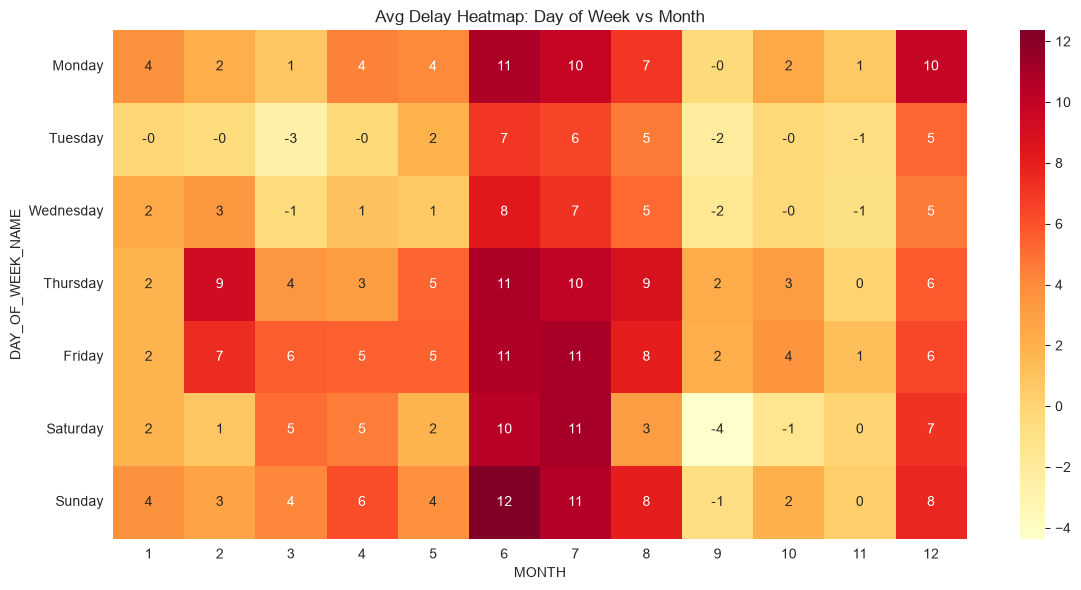

In [17]:
pivot = flights_clean.pivot_table(values='ARR_DELAY', index='DAY_OF_WEEK_NAME',
                                    columns='MONTH', aggfunc='mean')
pivot = pivot.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f')
plt.title('Avg Delay Heatmap: Day of Week vs Month')
plt.tight_layout()
plt.savefig('outputs/figures/heatmap.png', dpi=150)
plt.show()

## Key Business Insights

1. **Carrier delays and late-aircraft delays dominate** as the leading causes of arrival delay, together outweighing weather, security, and NAS (air traffic system) delays combined — indicating most delays stem from airline-side operational issues rather than external factors.

2. **Summer months (June–July) show the highest average delays**, peaking on Sundays in June (avg ~12 min). September is consistently the best-performing month, with several days showing negative average delay (flights arriving early on average) — likely due to lower summer travel volume/weather disruption easing off.

3. **ABQ → JFK is the most delayed route** (avg 40.1 min delay across 109 flights), followed by ACK → LGA (38.9 min) and ASE → ORD (38.5 min) — a pattern of smaller regional airports feeding into congested major hubs. The best-performing route is ABE → CLT (avg -14.5 min, arriving over 14 minutes early on average).

4. **Endeavor Air, Horizon Air, and Delta lead on-time performance** (~87-88% on-time), while JetBlue, Frontier, and Allegiant trail (~74%). Separately, **PSA Airlines has the highest cancellation rate (3.08%)**, while **Hawaiian Airlines has the lowest (1.21%)** and also ranks among the better on-time performers — suggesting Hawaiian has the most reliable overall operations in this dataset.

5. **Weekday patterns**: Thursdays and Fridays show elevated delays even outside peak summer months, while Tuesdays and Wednesdays are consistently the calmest days to fly.